In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
import os

In [2]:
from sklearn.impute import SimpleImputer
cale_date = "../data/raw/Crop_recommendation.csv"
df = pd.read_csv(cale_date)
X = df.drop('label', axis=1)
y = df['label']

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

imputer = SimpleImputer(strategy='median')
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

In [3]:
modele_initiale = {
    "KNN": KNeighborsClassifier(),
    "SVM (RBF)": SVC(kernel='rbf', random_state=42),
    "Random Forest (Baseline)": RandomForestClassifier(random_state=42),
    "XGBoost": xgb.XGBClassifier(objective='multi:softprob', eval_metric='mlogloss', random_state=42, n_jobs=1)
}

print("=== ARENĂ DE BENCHMARKING MATEMATIC ===")
for nume, mod in modele_initiale.items():
    mod.fit(X_train_scaled, y_train)
    print(f"{nume} -> Train Acc: {mod.score(X_train_scaled, y_train)*100:.2f}% | Test Acc: {mod.score(X_test_scaled, y_test)*100:.2f}%")

=== ARENĂ DE BENCHMARKING MATEMATIC ===
KNN -> Train Acc: 98.47% | Test Acc: 97.95%
SVM (RBF) -> Train Acc: 98.58% | Test Acc: 98.41%
Random Forest (Baseline) -> Train Acc: 100.00% | Test Acc: 99.55%
XGBoost -> Train Acc: 100.00% | Test Acc: 99.32%


In [4]:
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [6, 8, 10],
    'min_samples_split': [4, 6, 10],
    'max_features': ['sqrt']
}

cv_stratificat = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=cv_stratificat,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)
model_final = grid_search.best_estimator_

print(f"Cei mai buni hiperparametri rezultați: {grid_search.best_params_}")
print(f"Acuratețe stabilizată prin Cross-Validation pe Train: {grid_search.best_score_ * 100:.2f}%")

Cei mai buni hiperparametri rezultați: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_split': 10, 'n_estimators': 150}
Acuratețe stabilizată prin Cross-Validation pe Train: 99.43%


In [5]:
y_pred = model_final.predict(X_test_scaled)
f1_ponderat = f1_score(y_test, y_pred, average='weighted')
print(f"Acuratețe pe setul de test independent: {model_final.score(X_test_scaled, y_test)*100:.2f}%")
print(f"Weighted F1-Score Final: {f1_ponderat*100:.2f}%")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

Acuratețe pe setul de test independent: 99.55%
Weighted F1-Score Final: 99.55%
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      0.95      0.97        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      1.00      0.98        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      1.00      1.00        20
       maize       0.95      1.00      0.98        20
       mango       1.00      1.00      1.00        20
   mothbeans       1.00      1.00      1.00        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
  

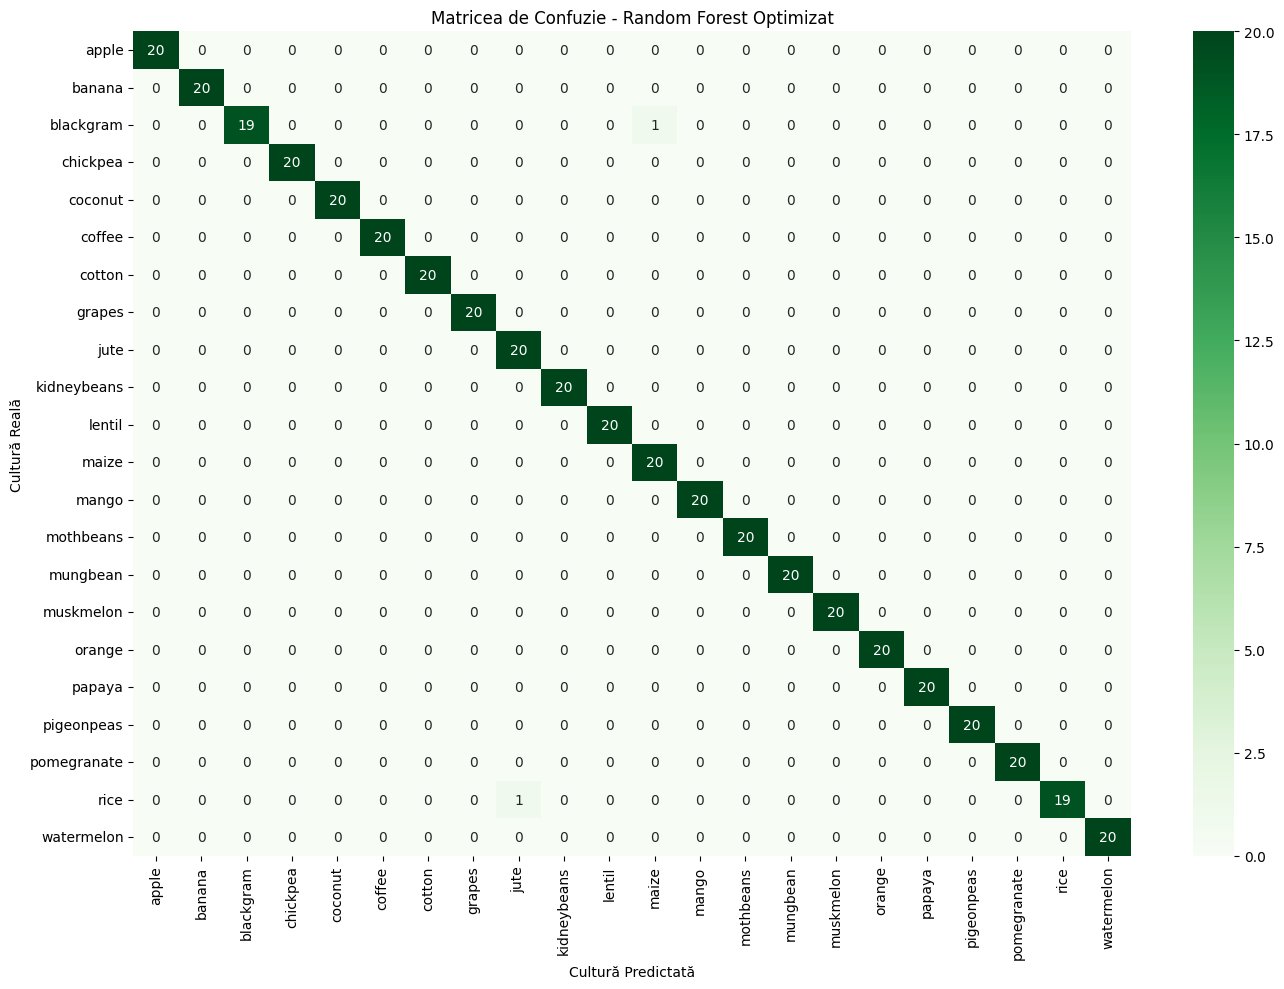

✅ Salvare finalizată cu denumirea corectă de producție!


In [6]:
plt.figure(figsize=(14, 10))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Greens',
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Matricea de Confuzie - Random Forest Optimizat')
plt.ylabel('Cultură Reală')
plt.xlabel('Cultură Predictată')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

os.makedirs('../models', exist_ok=True)
joblib.dump(model_final, '../models/random_forest_soil_model.pkl')
joblib.dump(scaler, '../models/soil_scaler.pkl')
joblib.dump(label_encoder, '../models/soil_label_encoder.pkl')
print("✅ Salvare finalizată cu denumirea corectă de producție!")